# Машинное обучение, ФКН ВШЭ

# Практическое задание 9. Несбалансированные задачи

## Общая информация
Дата выдачи: 01.03.2026

Мягкий дедлайн: 15.03.2026 23:59 MSK

Жесткий дедлайн: 22.03.2026 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-xx-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этом задании мы разберем основные техники работы в задачах, где один из классов занимает существенно меньшую долю выборки, чем остальные. Для простоты мы обойдемся бинарной задачей, тем не менее, во многом данные методы можно перенести и на задачи с б**о**льшим числом классов. Кроме того, вы получите очередной бесценный опыт исследования случайной библиотеки случайных индусов с нуля.

In [17]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from tqdm.auto import tqdm

**Задание -1 (1 балл)**. EDA

В качестве данных для нашей работы возьмем выложенный на kaggle датасет транзакций, в котором нужно выискивать мошеннические проводки: [клик](https://www.kaggle.com/mlg-ulb/creditcardfraud). Данная задача по определению подходит под несбалансированную, что можно сказать даже без наличия каких-либо данных (понятно, что среди всех транзакций клиентов очень малая часть будет мошеннической).

Загрузим данные, проведем некоторые классические манипуляции.

In [18]:
!gdown 190_kQrc1e0uZDdXw_lKocH_f5ERu93HL -O creditcard.csv

Downloading...
From (original): https://drive.google.com/uc?id=190_kQrc1e0uZDdXw_lKocH_f5ERu93HL
From (redirected): https://drive.google.com/uc?id=190_kQrc1e0uZDdXw_lKocH_f5ERu93HL&confirm=t&uuid=590dbabc-da60-4d96-a851-dba0d0d76313
To: /content/creditcard.csv
100% 151M/151M [00:01<00:00, 104MB/s]


In [19]:
df = pd.read_csv('creditcard.csv')

In [20]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Наши данные были анонимизированы. Мы имеем 30 признаков, из которых 28 - это результаты PCA-преобразования на исходном датасете. Еще 2 признака представляют собой время в секундах, прошедшее с момента первой транзакции в датасете, и размер транзакции. Скажите, какова доля положительных объектов в выборке?

In [21]:
print(f'Доля положительного класса: {df['Class'].sum() / df.shape[0]:.4f}')

Доля положительного класса: 0.0017


Начнем с обработки времени. Секунды сами по себе не несут большой информации о зависимостях в данных, попробуйте по ним создать признаки "час" (от 0 до 23) и "день" (от 0 до ...) в аналогичной манере (принимая первый объект выборки за начальную точку). Сколько дней покрывают данные?

In [22]:
hours = pd.Series([i // 3600 % 24 for i in df['Time']], name='hour')
days = pd.Series([i // (3600 * 24) for i in df['Time']], name='day')
df = pd.concat([df, hours, days], axis=1)

In [23]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour,day
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.0,1.0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.0,1.0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.0,1.0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.0,1.0


In [24]:
print(f'Кол-во покрытых дней: {df['day'].max()}')

Кол-во покрытых дней: 1.0


Постройте следующие графики:

1. Распределение числа транзакций по каждому часу (line-plot).
2. Распределение доли мошеннических транзакций по каждому часу (line-plot)
3. То же самое для дней (здесь можно использовать bar-plot, так как дней должно быть немного).

Какие выводы можно сделать из графиков? На ваш взгляд, как можно связать полученные нами часы с реальными часами в сутках?

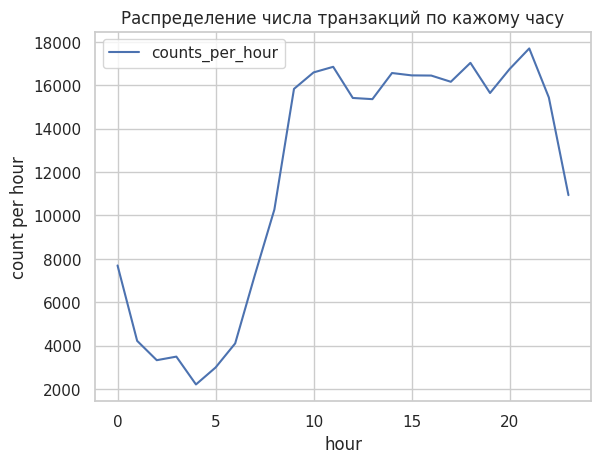

In [25]:
counts_per_hour = df.groupby('hour').size().to_frame('counts_per_hour')
sns.lineplot(counts_per_hour)
plt.title('Распределение числа транзакций по кажому часу')
plt.ylabel('count per hour')
plt.show()

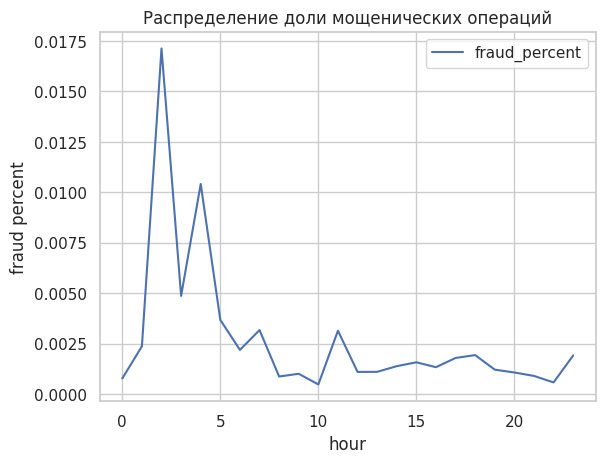

In [26]:
fraud_percent = df.groupby('hour')['Class'].mean().to_frame('fraud_percent')
sns.lineplot(fraud_percent)
plt.title('Распределение доли мощенических операций')
plt.ylabel('fraud percent')
plt.show()

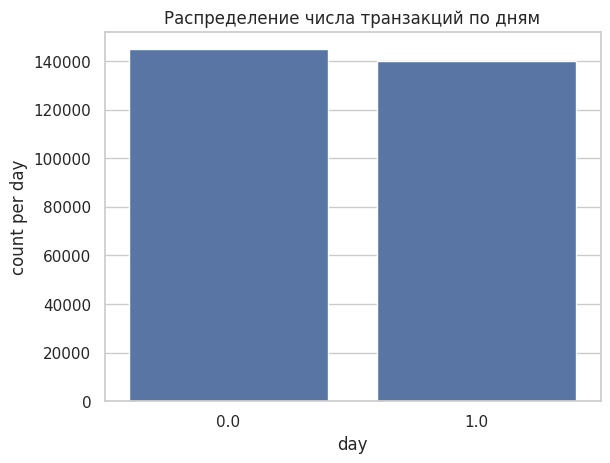

In [27]:
sns.countplot(data=df, x='day')
plt.title('Распределение числа транзакций по дням')
plt.ylabel('count per day')
plt.show()

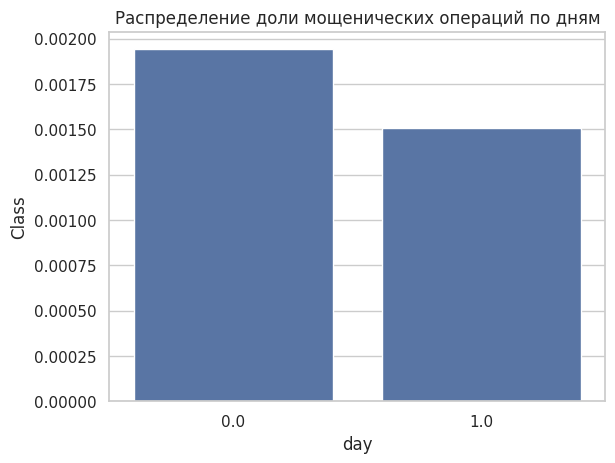

In [28]:
sns.barplot(data=df, x='day', y='Class', errorbar=None)
plt.title('Распределение доли мощенических операций по дням')
plt.show()

Ответ: Полученные часы хорошо соотносятся с часами дня, так как для часов с 0 до 6 активность наименьшая, так как в это время люди спят. Далее в течении дня активность держится примерно на одном уровне и вечером она начинает падать. Пик мошенической активности наступает ночью.  
В обоих днях количество операций несильно отличается, но доля мошенических операций в первый день выше.

С анонимизированными признаками вряд ли можно придумать что-то интересное. Попробуйте (например, с помощью корреляции?) выбрать несколько наиболее важных признаков и поглядеть на различия в их распределении для разных классов.

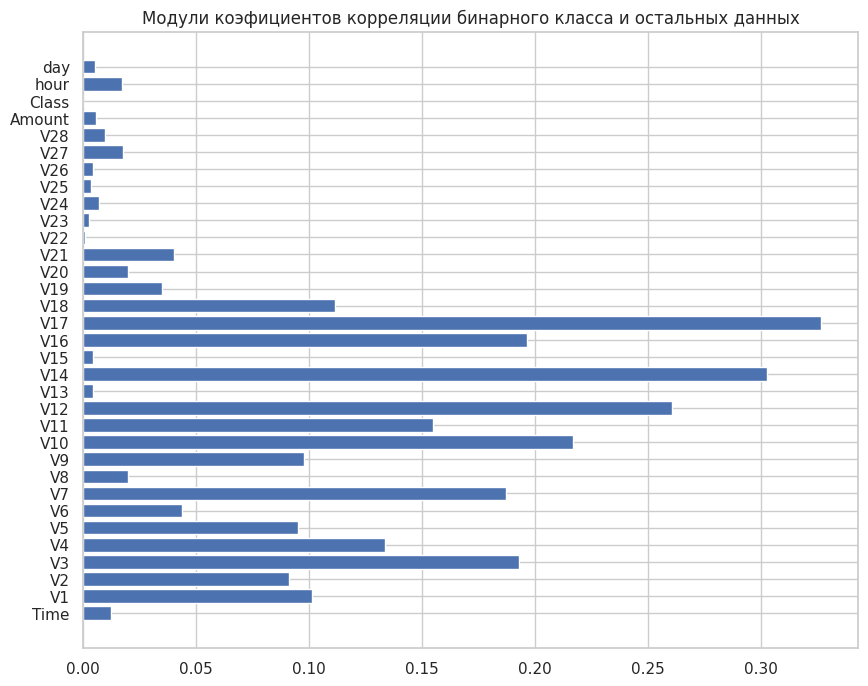

In [29]:
cor = df.corr()
for i in range(df.shape[1]):
    cor.iloc[i, i] = 0

plt.figure(figsize=(10, 8))
plt.title('Модули коэфициентов корреляции бинарного класса и остальных данных')
plt.barh(df.columns, width=np.abs(cor['Class']))
plt.show()

Сильнее всего с 'Class' коррелируют V17, V14, V12

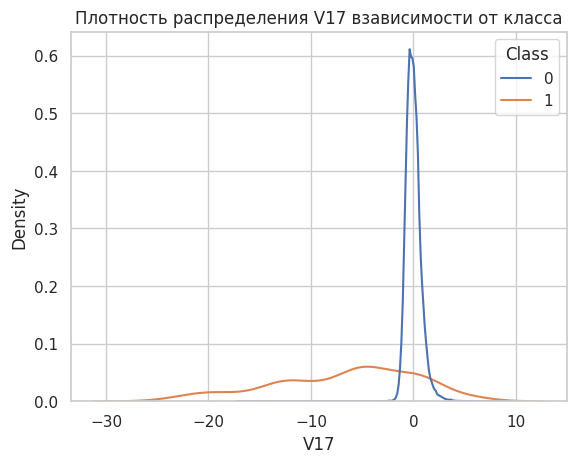

In [30]:
sns.kdeplot(data=df, x='V17', hue='Class', common_norm=False)
plt.title('Плотность распределения V17 взависимости от класса')
plt.show()

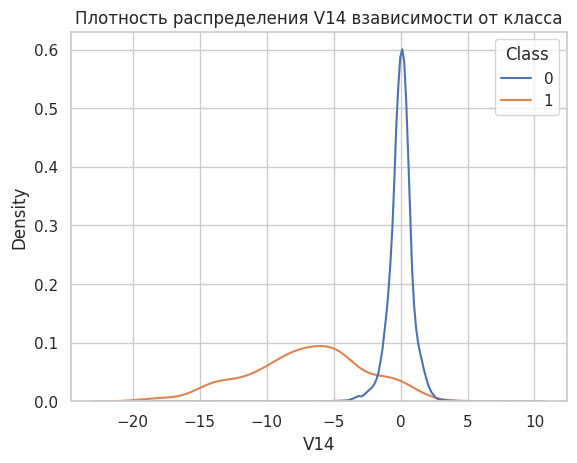

In [31]:
sns.kdeplot(data=df, x='V14', hue='Class', common_norm=False)
plt.title('Плотность распределения V14 взависимости от класса')
plt.show()

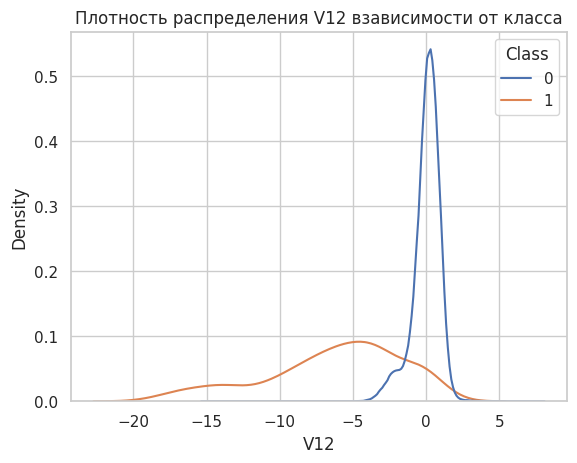

In [32]:
sns.kdeplot(data=df, x='V12', hue='Class', common_norm=False)
plt.title('Плотность распределения V12 взависимости от класса')
plt.show()

У нормальных операций значения этих признаков имеют меньшую дисперсию и сосредоточены вокруг 0. Мошенические операции в этих признаках имеют побольшей части отрицательные значения и распределены с гораздо большей дисперсией.

Теперь давайте разделим данные. Отделите хронологически последние 20% транзакций и поделите их пополам (также хронологически, т.е. без перемешивания) на валидационные и тестовые. Это разбиение не совсем корректно (как можно было заметить, мошеннические транзакции имеют разное распределение во времени - по-хорошему, нам стоило бы выделить целые сутки записей как под валидацию, так и под тест), тем не менее, мы не сможем получить больше данных для адекватного контроля, поэтому обойдемся этим.

In [33]:
idx80 = int(0.8 * df.shape[0])
idx90 = int(0.9 * df.shape[0])
X_train = df.drop(columns=['Class']).iloc[0:idx80]
y_train = df['Class'].iloc[0:idx80]
X_val = df.drop(columns=['Class']).iloc[idx80+1:idx90]
y_val = df['Class'].iloc[idx80+1:idx90]
X_test = df.drop(columns=['Class']).iloc[idx90+1:]
y_test = df['Class'].iloc[idx90+1:]

# Часть 1. Несбалансированная классификация.

**Задание 0. (1 балл)**: перед началом работы давайте поговорим о том, как мы будем оценивать качество. Классические метрики для качества классификации чаще всего "ломаются" на задачах с сильным перекосом. Чему будет равно значение accuracy для наивного предсказания (= мажорный класс для каждого объекта)? (можете не отвечать, просто подумайте)

Из курса МО-1 вам уже известно, что мы можем использовать в таких задачах `AUC-PR` и получать адекватные показатели. Можно сказать, что `AUC-PR` представляет собой матожидание `precision` по распределению, заданному выигрышем в `recall` при смене порога.

In [34]:
from sklearn.metrics import precision_recall_curve, auc

def pr_auc_score(y_true, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    return auc(recall, precision)

Тем не менее, существуют и другие, не менее интересные метрики. Одной из таких метрик является коэффициент Каппа Коэна, представляющий собой нормализованную `accuracy`:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Данная метрика служит в качестве меры согласованности между двумя независимыми предсказателями, но ничего не знает про "верные" и "предсказанные" метки (в отличие от многих других метрик машинного обучения). Здесь $p_o$ - доля согласованных предсказаний, а $p_e$ - доля согласованных предсказаний, которая могла бы получиться при случайных ответах предсказателей. В нашем случае это работает так:

• В качестве $p_o$ берем accuracy

• В качестве $p_e$ примем следующую величину - вероятность случайного соглашения позитивных ответов (произведение долей позитивных ответов в обоих предсказаниях) плюс вероятность случайного соглашения негативных ответов (произведение долей негативных ответов в обоих предсказаниях)

Метрика принимает значения от -1 до 1, где 1 - полная согласованность, 0 - согласованность на уровне рандома, -1 - совсем плохо. Как уже говорилось, метрика не различает "верные" и "предсказанные" метки, поэтому является симметричной (можете использовать это для отладки):

In [35]:
from sklearn.metrics import accuracy_score

def cohen_kappa(y_true, y_pred, threshold=0.5, probs=False):
    if probs:
        y_pred = (y_pred > threshold).astype(np.float64)
    p0 = accuracy_score(y_true, y_pred)
    pe = np.mean(y_true) * np.mean(y_pred) + (1-np.mean(y_true)) * (1 - np.mean(y_pred))
    return (p0 - pe) / (1 - pe)

Еще одной метрикой в такой задаче служит коэффициент корреляции Мэтьюза, выражающийся в терминах матрицы ошибок следующим образом:

$$\text{MCC} = \frac{TP\times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

Метрика принимает значения от -1 до 1, интерпретируемые аналогичным образом.

In [36]:
from sklearn.metrics import confusion_matrix

def mcc(y_true, y_pred, threshold=0.5, probs=False):
    if probs:
        y_pred = (y_pred > threshold).astype(np.float64)
    m = confusion_matrix(y_true, y_pred)
    if (m[1][1] + m[0][1]) * (m[1][1] + m[1][0]) * (m[0][0] + m[0][1]) * (m[0][0] + m[1][0]) == 0:
        return 0.0
    mcc = (m[1][1] * m[0][0] - m[1][0] * m[0][1]) / np.sqrt((m[1][1] + m[0][1]) * (m[1][1] + m[1][0]) * (m[0][0] + m[0][1]) * (m[0][0] + m[1][0]))
    return mcc

Обратите внимание, что эти метрики вычисляются на бинаризованных предсказаниях, поэтому может иметь смысл дополнительная настройка порога бинаризации.

Давайте проверим, что наши метрики действительно подходят под задачу. Вычислите их значения для наивного предсказания (aka мажорный класс для всех объектов):

In [21]:
y_true = df['Class'].to_numpy()
y_pred = np.zeros(df.shape[0])

print(f"PR AUC: {pr_auc_score(y_true, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_true, y_pred)}")
print(f"MCC: {mcc(y_true, y_pred)}")

PR AUC: 0.50086374281531
Cohen Kappa Coef: 0.0
MCC: 0.0


Давайте запустим бейзлайн-решение для нашей задачи. С чего же начнем? Возьмите `catboost` и обучите его классификатор на наших данных (используйте все признаки). Вычислите значения всех метрик на тестовой части, для контроля переобучения используйте валидационную (здесь и далее везде, где фигурирует `catboost`).

In [37]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [41]:
from catboost import CatBoostClassifier

In [ ]:
cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train, y_train)

CatBoostClassifier(verbose=False)

In [ ]:
y_pred = cbc.predict_proba(X_test)[:, 1]

print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred)}")
print(f"MCC: {mcc(y_test, y_pred)}")

PR AUC: 0.6968089153011032
Cohen Kappa Coef: 0.7366708089236023
MCC: 0.7460414553685881


Если вы все сделали правильно, у вас должны были получиться значения в районе 0.7.

**Задание 1. (1 балл)**. Многие реализации методов предлагают встроенные способы для борьбы с нашей проблемой. Самое часто встречающееся решение - просто добавить вес в функции потерь для минорного класса (таким образом, ошибка на объекте минорного класса будет весить больше, чем для мажорного). В `catboost` это также реализовано, причем для бинарной задачи это можно сделать целыми двумя способами (можете выбрать любой, на свой вкус, автор задания предпочитает отдельный скейлинг для минорного класса). Чаще всего в качестве веса берется отношение числа объектов мажорного класса к числу минорного. Попробуйте обучить модель с таким скалированием и сравните метрики на тестовой части с бейзлайном.

In [ ]:
scale = np.sum(y_train == 0) / np.sum(y_train == 1)

cbc = CatBoostClassifier(verbose=False, scale_pos_weight=scale)
cbc.fit(X_train, y_train)

CatBoostClassifier(scale_pos_weight=np.float64(545.3908872901678), verbose=False)

In [ ]:
y_pred = cbc.predict_proba(X_test)[:, 1]

print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred)}")
print(f"MCC: {mcc(y_test, y_pred)}")

PR AUC: 0.7454245906410368
Cohen Kappa Coef: 0.7231767679033426
MCC: 0.7246569225307383


Поскольку данный вес будет являться гиперпараметром метода, было бы опрометчиво остановиться на одном значении (тем более, с большой вероятностью у вас все сломалось). Запустите перебор для этого гиперпараметра на валидационной выборке (используйте `PR-AUC`), подберите оптимальный порог бинаризации для $\kappa$ или $\text{MCC}$. Для лучшего найденного веса и порога вычислите все метрики на тестовой части.

При этом можете также проверить отдельное скалирование в большую сторону для мажорного класса (т.е. веса минорного сделать меньше 1) и экстремальные скалирования (т.е. веса минорного больше, чем в начале этого задания). Какой вес получился оптимальным?

In [ ]:
try_scale = [0.75 * scale, 0.85 * scale, 0.95 * scale, scale, 1.05 * scale, 1.15 * scale, 1.25 * scale]
best_scale = None
best_pr = None

for w in try_scale:
    cbc = CatBoostClassifier(verbose=False, scale_pos_weight=w)
    cbc.fit(X_train, y_train)
    y_pred = cbc.predict_proba(X_val)[:, 1]
    cur_pr = pr_auc_score(y_val, y_pred)
    if best_scale is None or cur_pr > best_pr:
        best_scale = w
        best_pr = cur_pr

In [ ]:
print(f'Best scale: {best_scale}, gives PR AUC: {best_pr} on validation')

Best scale: 681.7386091127098, gives PR AUC: 0.8338398499324018 on validation


In [ ]:
cbc = CatBoostClassifier(verbose=False, scale_pos_weight=best_scale)
cbc.fit(X_train, y_train)

CatBoostClassifier(scale_pos_weight=np.float64(681.7386091127098), verbose=False)

In [ ]:
try_threshold = np.linspace(0.2, 0.8, 50)

best_threshold = None
best_mcc = None
for threshold in try_threshold:
    y_pred = cbc.predict_proba(X_val)[:,1]
    cur_mcc = mcc(y_val, y_pred, threshold, True)
    if best_mcc is None or cur_mcc > best_mcc:
        best_mcc = cur_mcc
        best_threshold = threshold

In [ ]:
print(f'Best threshold: {best_threshold}, gives MCC: {best_mcc} on validation')

Best threshold: 0.6408163265306124, gives MCC: 0.8586097583901925 on validation


In [ ]:
y_pred = cbc.predict_proba(X_test)[:, 1]

print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

PR AUC: 0.7450736081469793
Cohen Kappa Coef: 0.6663874848451028
MCC: 0.6687173700279536


**Задание 2. (1 балл)**. На самом деле, то, что мы сейчас делали, очень схоже с другой распространенной техникой - оверсэмплингом. Фактически, мы можем продублировать все объекты минорного класса и получить тот же эффект, какой был бы при использовании веса, равного 2. Тем не менее, такой подход - это лишь малая часть того, что мы можем проделать с целью повысить число объектов минорного класса.

Для продолжения работы установим библиотеку [imbalanced-learn](https://imbalanced-learn.org/stable/):

In [38]:
!pip3 install imbalanced-learn
# conda install -c conda-forge imbalanced-learn

Первый метод, которым мы воспользуемся, называется SMOTE (его вы уже разбирали на лекции). Кратко напомним суть: мы выбираем случайного кандидата среди $k$ ближайших соседей объекта минорного класса, затем берем точку на отрезке между двумя объектами (т.е. выпуклую комбинацию со случайными коэффициентами) и добавляем в выборку.

In [ ]:
from imblearn.over_sampling import SMOTE

Используйте SMOTE для ресэмплинга обучающей выборки, на новой выборке обучите модель (вес положительных объектов скалировать не нужно). Замерьте качество на тестовой выборке (**важно!** не преобразовывайте валидационную и тестовую выборку никак - мы не хотим отслеживать качество на объектах, которых в реальности не существует). Сравните полное выравнивание выборки с частичным (т.е. таким, что баланс классов улучшается, но не достигает равенства - скажем, 1:2 и 1:10).

In [ ]:
resamp = SMOTE(random_state=42)
X_train_res, y_train_res = resamp.fit_resample(X_train, y_train)

cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)

y_pred = cbc.predict_proba(X_test)[:, 1]
print("Full alignment")
print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

Full alignment
PR AUC: 0.7347089595333274
Cohen Kappa Coef: 0.7108828132076715
MCC: 0.711058682604368


In [ ]:
resamp = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = resamp.fit_resample(X_train, y_train)

cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)

y_pred = cbc.predict_proba(X_test)[:, 1]
print("Fraud:Not Fraud = 1:2")
print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

Fraud:Not Fraud = 1:2
PR AUC: 0.7404528364624378
Cohen Kappa Coef: 0.7803305326161849
MCC: 0.7824309044727329


In [ ]:
resamp = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = resamp.fit_resample(X_train, y_train)

cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)

y_pred = cbc.predict_proba(X_test)[:, 1]
print("Fraud:Not Fraud = 1:10")
print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

Fraud:Not Fraud = 1:10
PR AUC: 0.7243174038413941
Cohen Kappa Coef: 0.7998608583214551
MCC: 0.8038960608087421


**Бонус (1.5 балла)**. Для vanilla SMOTE существуют некоторые модификации, часть из которых была реализована в библиотеке imblearn. Во время лекций/семинаров эти модификации не рассматривались, тем не менее, мы все равно их исследуем.

Найдите статьи о следующих методах и попробуйте вкратце сформулировать, в чем их основная идея (сделайте так, чтобы человек, знакомый с машинным обучением в целом, но не слышавший конкретно про это смог понять):

BorderlineSMOTE - Авторы статье считают, что объекты находящиеся ближе к границе классов важнее для обучения, так как их легче неправильно классифицировать. Предлагается для каждого объекта из меньшего класса найтится его k ближайщих соседей во всей обучающей выборке, если они все из другого класса, то это шум. Если число ближайших соседей принадлежащих другому классу находится в заданном диапозоне, то этот объект помещается в множество DANGER. Для объектов из этого множества и производится генерация новых объектов.

SVM-SMOTE - Находим границу классов с помощью SVM и генерируем объекты основываясь на точкая меньшего класса, которые находятся рядом с границей.

K-Means-SMOTE - Применям K-Means к данным. Для каждого полученного кластера считается соотношение классов. Если соотношение в кластере проходит порог, то в данные из него будут использоваться для генерации новых данных.

ADASYN - Для каждого объекта меньшего класса подсчитывается какая доля его сосдей принадлежат другому классу. Эти сложности нормирубтся и по ним опредляется, сколько объектов нужно сосздать рядом с конкретным объектом меньшего класса. Больше все объектов создается рядом со сложными объектами

Теперь попробуйте сравнить качество всех методов на наших данных.

In [39]:
from imblearn.over_sampling import BorderlineSMOTE, SVMSMOTE, KMeansSMOTE, ADASYN

In [45]:
b_smote = BorderlineSMOTE(random_state=42)
X_train_res, y_train_res = b_smote.fit_resample(X_train, y_train)

cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)

y_pred = cbc.predict_proba(X_test)[:, 1]
print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

PR AUC: 0.6688620830006493
Cohen Kappa Coef: 0.7439928872385557
MCC: 0.7441944609774699


In [46]:
b_smote = SVMSMOTE(random_state=42)
X_train_res, y_train_res = b_smote.fit_resample(X_train, y_train)

cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)

y_pred = cbc.predict_proba(X_test)[:, 1]
print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, 0.6408163265306124, True)}")
print(f"MCC: {mcc(y_test, y_pred, 0.6408163265306124, True)}")

PR AUC: 0.69587501762881
Cohen Kappa Coef: 0.7439928872385557
MCC: 0.7441944609774699


In [54]:
b_smote = KMeansSMOTE(random_state=42, cluster_balance_threshold=0.001)
X_train_res, y_train_res = b_smote.fit_resample(X_train, y_train)

cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)

y_pred = cbc.predict_proba(X_test)[:, 1]
print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

PR AUC: 0.7248117355588698
Cohen Kappa Coef: 0.7108828132076715
MCC: 0.711058682604368


In [56]:
b_smote = ADASYN(random_state=42)
X_train_res, y_train_res = b_smote.fit_resample(X_train, y_train)

cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)

y_pred = cbc.predict_proba(X_test)[:, 1]
print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

PR AUC: 0.7233178906568889
Cohen Kappa Coef: 0.6150414965802498
MCC: 0.6224653705499544


**Задание 3. (1 балл)**. До этого момента все наши решения концентрировались на работе с минорным классом. Теперь давайте попробуем зайти с другой стороны. Может быть, для восстановления закономерностей нам не нужно столько объектов мажорного класса, и они просто засоряют нам выборку лишней информацией?

Для решения этой проблемы существуют методы андерсэмплинга. Самое простое, что можно придумать - удалять точки мажорного класса, пока мы не получим приемлемый баланс. Протестируйте следующий метод и постройте графики достигаемых значений метрик от баланса классов и от отношения размеров исходной и пересэмпленной выборки:

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
balances_labels = ['1:1', '1:2', '1:3', '1:5', '1:10', '1:50','1:100', '1:200']
balances = ['auto', 0.5, 0.33, 0.2, 0.1, 0.02, 0.01, 0.005]
size_ratio = []

pr_list = []
cohen_list = []
mcc_list = []

for strat in balances:
    resampler = RandomUnderSampler(sampling_strategy=strat, random_state=42)
    X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)
    size_ratio.append(X_train_res.shape[0] / X_train.shape[0])
    cbc = CatBoostClassifier(verbose=False)
    cbc.fit(X_train_res, y_train_res)
    y_pred = cbc.predict_proba(X_val)[:,1]
    pr_list.append(pr_auc_score(y_val, y_pred))
    cohen_list.append(cohen_kappa(y_val, y_pred, best_threshold, True))
    mcc_list.append(mcc(y_val, y_pred, best_threshold, True))

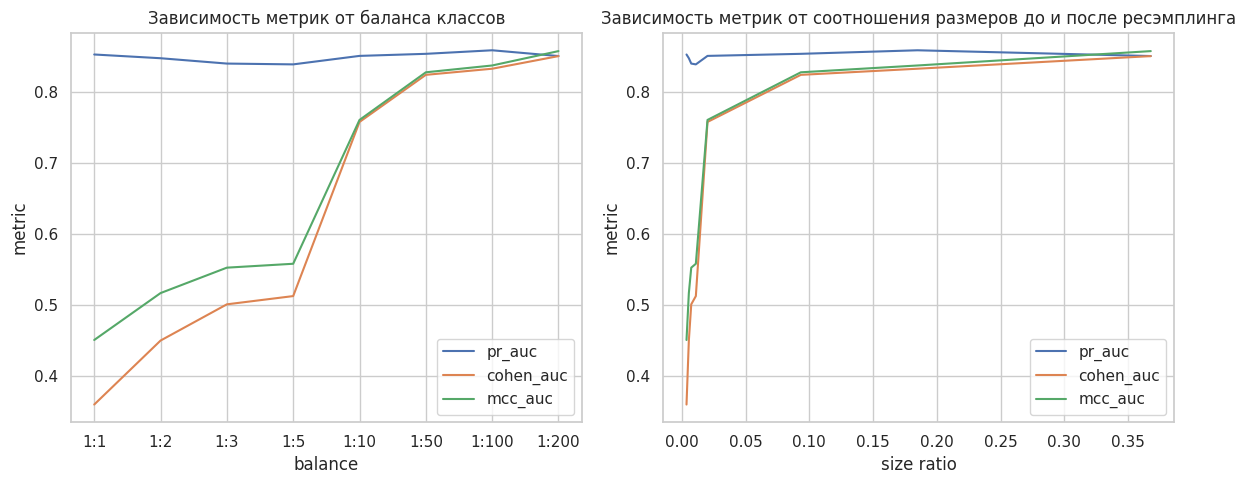

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(balances_labels, pr_list, label='pr_auc')
axes[0].plot(balances_labels, cohen_list, label='cohen_auc')
axes[0].plot(balances_labels, mcc_list, label='mcc_auc')
axes[0].set_title('Зависимость метрик от баланса классов')
axes[0].set_ylabel('metric')
axes[0].set_xlabel('balance')

axes[1].plot(size_ratio, pr_list, label='pr_auc')
axes[1].plot(size_ratio, cohen_list, label='cohen_auc')
axes[1].plot(size_ratio, mcc_list, label='mcc_auc')
axes[1].set_title('Зависимость метрик от соотношения размеров до и после ресэмплинга')
axes[1].set_ylabel('metric')
axes[1].set_xlabel('size ratio')

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
resampler = RandomUnderSampler(sampling_strategy=0.005, random_state=42)
X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)
cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)
y_pred = cbc.predict_proba(X_test)[:, 1]

print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

PR AUC: 0.6462500255071016
Cohen Kappa Coef: 0.7140753630948257
MCC: 0.7148875484691101


Даже такой наивный подход может дать относительно неплохие результаты и улучшить наши метрики. Тем не менее, сейчас мы никак не используем информацию о распределении объектов в выборке. Оказывается, что даже относительно простые эвристические правила могут заметно поднять нам качество - например, мы можем при отбрасывании использовать близость отдельных объектов мажорного класса к минорному и отбрасывать самые близкие. Протестируйте алгоритм [Near-Miss](https://www.site.uottawa.ca/~nat/Workshop2003/jzhang.pdf) на наших данных и постройте графики, аналогичные предыдущему пункту (также добавьте график с зависимостью качества от числа соседей).

In [ ]:
from imblearn.under_sampling import NearMiss

balances_labels = ['1:1', '1:2', '1:3', '1:5', '1:10', '1:50','1:100', '1:200', '1:500']
balances = ['auto', 0.5, 0.33, 0.2, 0.1, 0.02, 0.01, 0.005, 0.002]

pr_list = []
cohen_list = []
mcc_list = []
size_ratio = []

for strat in balances:
    resampler = NearMiss(sampling_strategy=strat)
    X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)
    size_ratio.append(X_train_res.shape[0] / X_train.shape[0])
    cbc = CatBoostClassifier(verbose=False)
    cbc.fit(X_train_res, y_train_res)
    y_pred = cbc.predict_proba(X_val)[:,1]
    pr_list.append(pr_auc_score(y_val, y_pred))
    cohen_list.append(cohen_kappa(y_val, y_pred, best_threshold, True))
    mcc_list.append(mcc(y_val, y_pred, best_threshold, True))

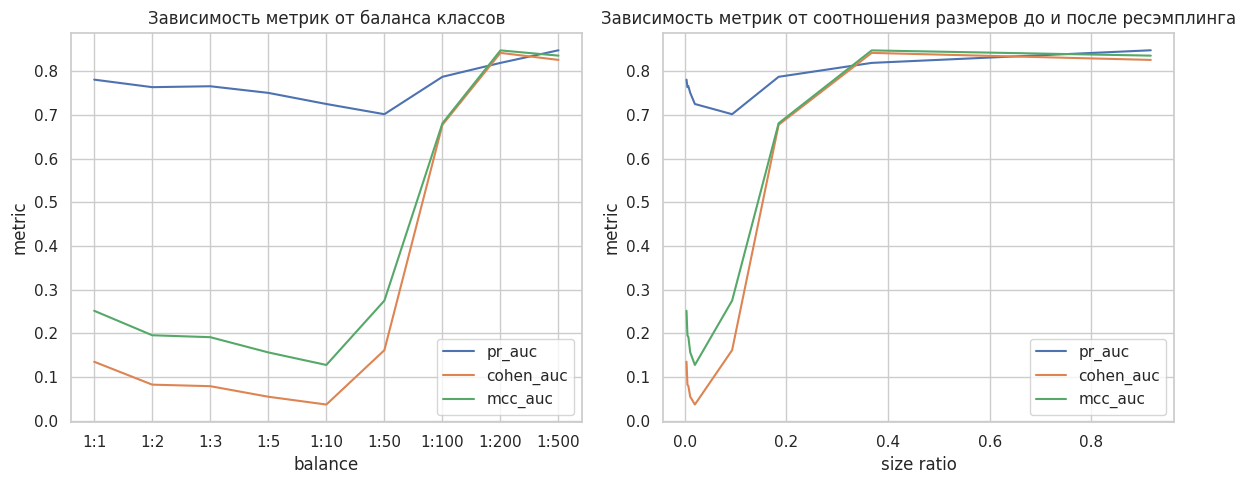

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(balances_labels, pr_list, label='pr_auc')
axes[0].plot(balances_labels, cohen_list, label='cohen_auc')
axes[0].plot(balances_labels, mcc_list, label='mcc_auc')
axes[0].set_title('Зависимость метрик от баланса классов')
axes[0].set_ylabel('metric')
axes[0].set_xlabel('balance')

axes[1].plot(size_ratio, pr_list, label='pr_auc')
axes[1].plot(size_ratio, cohen_list, label='cohen_auc')
axes[1].plot(size_ratio, mcc_list, label='mcc_auc')
axes[1].set_title('Зависимость метрик от соотношения размеров до и после ресэмплинга')
axes[1].set_ylabel('metric')
axes[1].set_xlabel('size ratio')

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
resampler = NearMiss(sampling_strategy=0.005)
X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)
cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)
y_pred = cbc.predict_proba(X_test)[:, 1]

print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

PR AUC: 0.589741693815166
Cohen Kappa Coef: 0.6815722052913723
MCC: 0.6815722052913704


In [ ]:
neighbors = [3, 5, 7, 10, 15]

pr_list = []
cohen_list = []
mcc_list = []

for n in neighbors:
    resampler = NearMiss(sampling_strategy=0.005, n_neighbors=n)
    X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)
    cbc = CatBoostClassifier(verbose=False)
    cbc.fit(X_train_res, y_train_res)
    y_pred = cbc.predict_proba(X_val)[:,1]
    pr_list.append(pr_auc_score(y_val, y_pred))
    cohen_list.append(cohen_kappa(y_val, y_pred, best_threshold, True))
    mcc_list.append(mcc(y_val, y_pred, best_threshold, True))

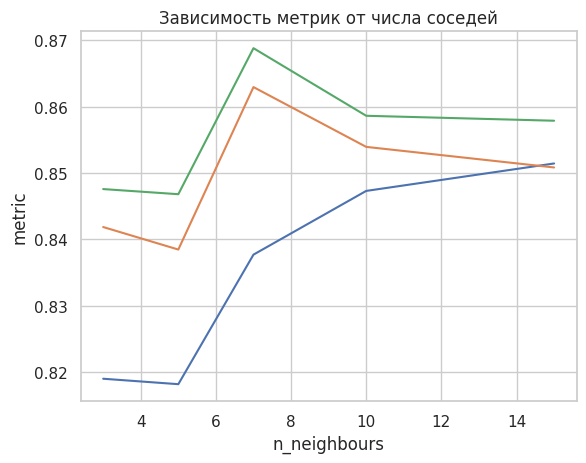

In [ ]:
plt.plot(neighbors, pr_list, label='pr_auc')
plt.plot(neighbors, cohen_list, label='cohen_auc')
plt.plot(neighbors, mcc_list, label='mcc_auc')
plt.title('Зависимость метрик от числа соседей')
plt.ylabel('metric')
plt.xlabel('n_neighbors')
plt.show()

In [ ]:
resampler = NearMiss(sampling_strategy=0.005, n_neighbors=5)
X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)
cbc = CatBoostClassifier(verbose=False)
cbc.fit(X_train_res, y_train_res)
y_pred = cbc.predict_proba(X_test)[:, 1]

print(f"PR AUC: {pr_auc_score(y_test, y_pred)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_pred, best_threshold, True)}")
print(f"MCC: {mcc(y_test, y_pred, best_threshold, True)}")

PR AUC: 0.5796958147691029
Cohen Kappa Coef: 0.6954066541178943
MCC: 0.6960659355559996


**Бонус (1 балл)**. imblearn также предлагает много различных методов для андерсэмплинга. Выберите что-нибудь еще из предлагаемого на свой вкус, опишите идею метода и протестируйте его.


# Часть 2. Поиск аномалий.

Как вы могли заметить, методы балансировки выборок очень часто могут привести к не самым лучшим результатам из-за того, что они по сути искажают информацию о реальном распределении данных - в реальности обычно требуется долгий подбор в принципе работоспособных для задачи методов и их аккуратная настройка.

Теперь давайте попробуем слегка сменить постановку задачи и переключиться на задачу "одноклассовой" классификации, то есть - поиска *аномалий* в выборке. В общем-то, это вполне согласуется с нашей областью работы - мы действительно можем назвать мошеннические транзакции аномальньми (как интуитивно, так и на основании наблюдаемой балансировки данных).

Стоит отметить, что методы обнаружения аномалий чаще всего относятся к классу методов обучения без учителя. Это дает некоторый положительный эффект - нам не обязательно нужно тратить время на разметку данных (тем не менее, для контроля качества какую-то часть разметить все-таки придется). Впрочем, чаще всего перфоманс таких методов оказывается заметно хуже, чем у честного обучения с учителем (если мы можем себе его позволить).



**Задание 4. (3 балла).** На занятиях вы разбирали схожий с Random Forest подход для детекции аномалий без известной разметки данных, называемый Isolation Forest. Напомним суть: на этапе обучения мы создаем ансамбль из решающих деревьев, в котором признак и порог на каждую вершину подбираются случайно. Затем мы считаем для объектов оценку аномальности через длину пути до соответствующего листа в каждом дереве.

В данном задании вам предлагается реализовать модификацию данного алгоритма, известную как Extended Isolation Forest. В ней мы на каждом шаге будем определять не порог для признака, а полноценную случайную гиперплоскость, разбивающую выборку на 2 части. С детальным описанием вы можете ознакомиться [здесь](https://arxiv.org/pdf/1811.02141.pdf).

Ниже приведен шаблон кода. Постарайтесь работать в его рамках (минорные изменения вполне допустимы, главное не переворачивайте всю структуру с ног на голову).

**NB**: будем считать, что в нашем датасете нет категориальных признаков - можете не заморачиваться с их обработкой (но в общем случае, это будет важно).

**Советы**:
 - Численные признаки лучше предобработать надлежащим образом.
 - Возможно, вам поможет выбрасывание некоторых признаков.
 - Внимательно следите за знаками.
 - Не игнорируйте документирующие строки.
 - Вероятнее всего, вы не сможете приблизиться по качеству к supervised-решениям. Если у вас не получается это сделать (но вы уверены в своей правоте), не стоит тратить слишком много времени на поиск ошибок.
- При желании, можете вынести этот код в отдельный файл и приложить его к ноутбуку. Он довольно громоздкий и в ноутбуке такое плохо читается.


**Бонусы (каждый по 0.5)**:
- Сделайте ваш EIF параллельным (`multiprocessing`, `joblib`).
- Добавьте возможность откатиться к дефолтному варианту Isolation Forest. (порассуждайте, как можно реализовать это в данной модели?):


In [57]:
def c_factor(n):
    """
    Computes average path length for an unsuccessful search in a binary search tree.
    Params:
        n: int - number of data points for BST
    """
    if n <= 1:
        return 0
    return 2 * (np.log(n-1) + 0.5772156649) - 2 * (n - 1) / n

def calc_height(X, depth, node):
    """
    Calculates anomaly scores for sample in a recursive manner.
    Params:
        X: np.array - current sample, available to node

        depth: int - path length up to current node

        node: Node - current tree node

    Returns:
        scores: int, float or np.array - anomaly scores for sample
    """
    scores = np.zeros(X.shape[0])

    if node.kind == 'external':
        scores += depth + c_factor(node.size)
        return scores

    X_left_idx = X @ node.w + node.b <= 0
    X_right_idx = X @ node.w + node.b > 0

    left_scores = calc_height(X[X_left_idx], depth+1, node.left)
    right_scores = calc_height(X[X_right_idx], depth+1, node.right)

    scores[X_left_idx] = left_scores
    scores[X_right_idx] = right_scores
    return scores



class Node(object):
    """
    A single node object for each tree. Contains information on height, current data,
    splitting hyperplane and children nodes.

    Attributes:
        X: np.array - data available to current node
        size: int - length of available data

        depth: int - depth of node

        left: Node - left child
        right: Node - right child

        kind: str - either "internal" or "external", indicates the type of current node

        w: np.array - normal vector for the splitting hyperplane
        b: float - intercept term for the splitting hyperplane
    """
    def __init__(self, X, depth, left, right, kind, w, b):
        """
        Node(h, left, right, kind, w, b)
        Represents the node object.

        Params:
            X: np.array - data available to current node
            depth: int - depth of node

            left: Node - left child
            right: Node - right child

            kind: str - either "internal" or "external", indicates the type of current node

            w: np.array - normal vector for the splitting hyperplane
            b: float - intercept term for the splitting hyperplane

        """
        self.size = X.shape[0]

        self.depth = depth

        self.left = left
        self.right = right

        self.kind = kind

        self.w = w
        self.b = b

    def __repr__(self):
        """
        For convenience only.
        """
        return f"Node(size={self.size}, depth={self.depth}, kind={self.kind})"

class RandomizedTree(object):
    """
    Single randomized tree object. Stores root and its depth (tree is built recursively).
    Attributes:
        depth: int - current tree depth

        max_depth: int - maximum tree depth

        root: Node - root node

        internal_count: int - number of internal nodes

        external_count: int - number of external nodes

    """
    def __init__(self, X, max_depth):
        """
        Single randomized tree object. Stores root and its depth (tree is built recursively).
        Params:
            X: np.array - train sample
            max_depth: int - maximum tree depth

        """
        self.depth = 0
        self.max_depth = max_depth

        self.internal_count = 0
        self.external_count = 0

        self.root = self.grow(X, 0)

    def __repr__(self):
        """
        For convenience only.
        """

        return f"RandomizedTree(depth={self.depth}, max_depth={self.max_depth}, n_internal={self.internal_count}, n_external={self.external_count})"



    def grow(self, X, depth):
        if depth == self.max_depth or X.shape[0] <= 1:
            self.external_count += 1
            self.depth = max(self.depth, depth + 1)
            return Node(X, depth, None, None, 'external', None, None)


        w = np.random.normal(0, 1, X.shape[1])
        projections = X @ w
        b = - np.random.uniform(projections.min(), projections.max())
        left_idx = (projections + b) <= 0
        right_idx = (projections + b) > 0

        left = self.grow(X[left_idx], depth + 1)
        right = self.grow(X[right_idx], depth + 1)
        self.internal_count += 1
        self.depth = max(self.depth, depth + 1)
        return Node(X, depth, left, right, 'internal', w, b)

    def score_samples(self, X):
        """
        Calculate anomaly scores for given data. You may utilize outer function `calc_height`.
        Params:
            X: np.array - data to be evaluated

        Returns:
            scores: np.array - estimated anomaly scores
        """
        if X.shape[0] == 0:
            return np.array([])
        scores = calc_height(X, 0, self.root)
        return scores


class ExtendedIsolationForest(object):
    """
    Extended Isolation Forest object. Stores training data and trained randomized trees.
    Attributes:
        n_trees: int - number of Randomized Trees

        max_depth: int - maximum depth of each tree

        subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree

        trees: list - container for trained trees

        contamination: float - estimated fraction of anomaly samples in data. Used for thresholding

    """

    def __init__(self, n_trees, subsample_rate, max_depth=None, contamination=0.01, random_seed=42):
        """
        Extended Isolation Forest object. Stores training data and trained randomized trees.
        Params:
            n_trees: int - number of Randomized Trees

            subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree

            max_depth: int or None - maximum depth of each tree. Defaults to ceil(log_2(subsample_size)) if not provided

            contamination: float - estimated fraction of anomaly samples in data. Used for thresholding

        """
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.subsample_rate = subsample_rate
        self.trees = []
        self.contamination = contamination
        self.is_fit = False
        self.subsample_size = None
        self.random_seed = random_seed

    def __repr__(self):
        """For convenience only."""

        return f"ExtendedIsolationForest(n_trees={self.n_trees}, max_depth={self.max_depth}, subsample_rate={self.subsample_rate}, contamination={self.contamination}, is_fit={self.is_fit})"

    def fit(self, X):
        """
        Fit EIF to new data.
        Params:
            X: np.array - 2d array of samples
        """
        self.subsample_size = int(self.subsample_rate * X.shape[0])
        np.random.seed(self.random_seed)
        if self.max_depth is None:
            self.max_depth = int(np.ceil(np.log2(self.subsample_size)))
        for i in range(self.n_trees):
            subsample = X[np.random.choice(X.shape[0], self.subsample_size, replace=False, )]
            self.trees.append(RandomizedTree(subsample, self.max_depth))
        self.is_fit = True
        return self

    def score_samples(self, X):
        """
        Estimate (normalized) anomaly score for each given sample
        Params:
            X: np.array - new samples

        Returns:
            scores: np.array - anomaly scores (larger value means higher probability of a sample being an outlier)
        """
        tree_scores = np.zeros(X.shape[0])
        for tree in self.trees:
            tree_scores += tree.score_samples(X)

        scores = 2 ** (- tree_scores / (c_factor(self.subsample_size) * self.n_trees))
        return scores


    def predict(self, X):
        """
        Predict if given samples are outliers.
        Params:
            X: np.array - new samples

        Returns:
            labels: np.array - anomaly labels (1 for outliers, 0 for inliers)
        """
        if not self.is_fit:
            assert self.is_fit
        scores = self.score_samples(X)
        threshold = np.percentile(scores, (1 - self.contamination) * 100)
        labels = scores >= threshold
        return labels


**Задание 5. (1 балл).** Протестируйте вашу реализацию EIF и подберите оптимальные гиперпараметры (наш метод не использует разметку, поэтому можете попробовать делать это на обучающей выборке). Сравните ее с обычным IF из `sklearn` (желательно делать это на одних и тех же параметрах). Удалось ли сделать лучше?

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [61]:
n_trees = [50, 100, 200, 300]

pr_list = []
cohen_list = []
mcc_list = []

for n in n_trees:
    eif = ExtendedIsolationForest(n, 0.8, None, )
    eif.fit(X_train_s)
    y_pred = eif.predict(X_test_s)
    y_pred_probs = eif.score_samples(X_test_s)
    pr_list.append(pr_auc_score(y_test, y_pred_probs))
    cohen_list.append(cohen_kappa(y_test, y_pred))
    mcc_list.append(mcc(y_test, y_pred))

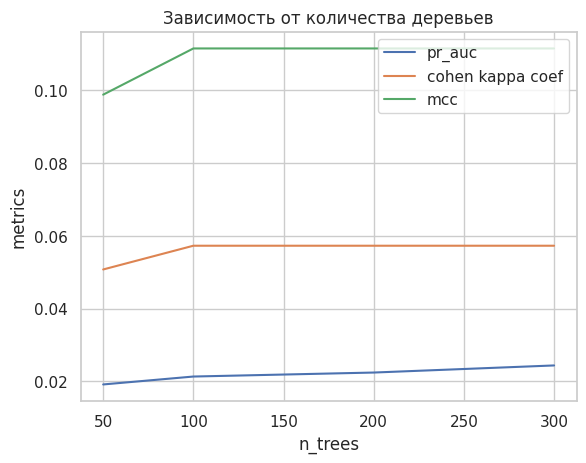

In [62]:
plt.plot(n_trees, pr_list, label='pr_auc')
plt.plot(n_trees, cohen_list, label='cohen kappa coef')
plt.plot(n_trees, mcc_list, label='mcc')
plt.legend()
plt.xlabel('n_trees')
plt.ylabel('metrics')
plt.title('Зависимость от количества деревьев')
plt.show()

In [64]:
subsample_rate = [0.2, 0.4, 0.5, 0.6, 0.8, 0.9]

pr_list = []
cohen_list = []
mcc_list = []

for rate in subsample_rate:
    eif = ExtendedIsolationForest(100, rate, None, 0.01)
    eif.fit(X_train_s)
    y_pred = eif.predict(X_test_s)
    y_pred_probs = eif.score_samples(X_test_s)
    pr_list.append(pr_auc_score(y_test, y_pred_probs))
    cohen_list.append(cohen_kappa(y_test, y_pred))
    mcc_list.append(mcc(y_test, y_pred))

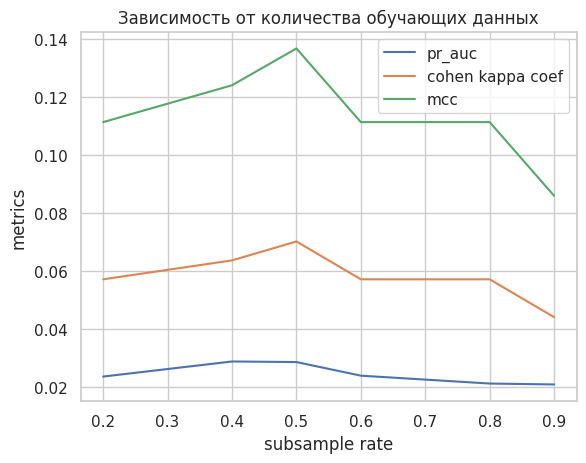

In [65]:
plt.plot(subsample_rate, pr_list, label='pr_auc')
plt.plot(subsample_rate, cohen_list, label='cohen kappa coef')
plt.plot(subsample_rate, mcc_list, label='mcc')
plt.legend()
plt.xlabel('subsample rate')
plt.ylabel('metrics')
plt.title('Зависимость от количества обучающих данных')
plt.show()

In [67]:
contamination = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

pr_list = []
cohen_list = []
mcc_list = []

for con in contamination:
    eif = ExtendedIsolationForest(100, 0.5, None, con)
    eif.fit(X_train_s)
    y_pred = eif.predict(X_test_s)
    y_pred_probs = eif.score_samples(X_test_s)
    pr_list.append(pr_auc_score(y_test, y_pred_probs))
    cohen_list.append(cohen_kappa(y_test, y_pred))
    mcc_list.append(mcc(y_test, y_pred))

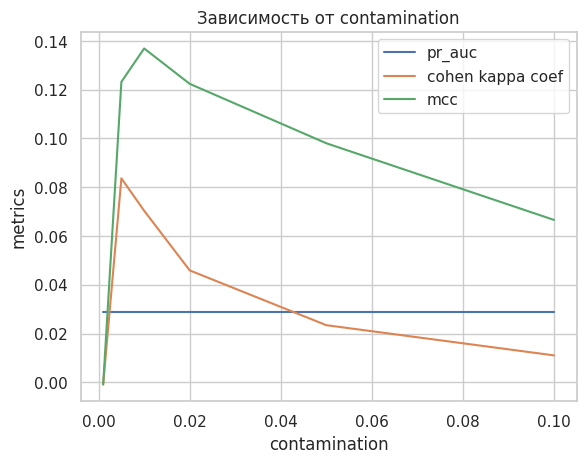

In [68]:
plt.plot(contamination, pr_list, label='pr_auc')
plt.plot(contamination, cohen_list, label='cohen kappa coef')
plt.plot(contamination, mcc_list, label='mcc')
plt.legend()
plt.xlabel('contamination')
plt.ylabel('metrics')
plt.title('Зависимость от contamination')
plt.show()

In [60]:
best_n = 100
best_rate = 0.5
best_con = 0.01

In [61]:
from sklearn.ensemble import IsolationForest

ifor = IsolationForest(n_estimators=best_n, max_samples=best_rate, contamination=best_con)
ifor.fit(X_train_s, y_train)
y_scores = 1 - ifor.score_samples(X_test)
y_labels = (ifor.predict(X_test_s) == -1).astype(int)
print(f"PR AUC: {pr_auc_score(y_test, y_scores)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_labels)}")
print(f"MCC: {mcc(y_test, y_labels)}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


PR AUC: 0.0281153889266601
Cohen Kappa Coef: 0.06354387387233315
MCC: 0.12956058113383773


Возможно, ваш алгоритм выдал большие оценки объектам с негативной разметкой. Постарайтесь выбрать несколько таких объектов и доступно объяснить (= с кодом и графиками), почему так вышло:

In [62]:
from sklearn.manifold import TSNE

In [64]:
false_negative = ((y_labels == 1) & (y_test == 0))

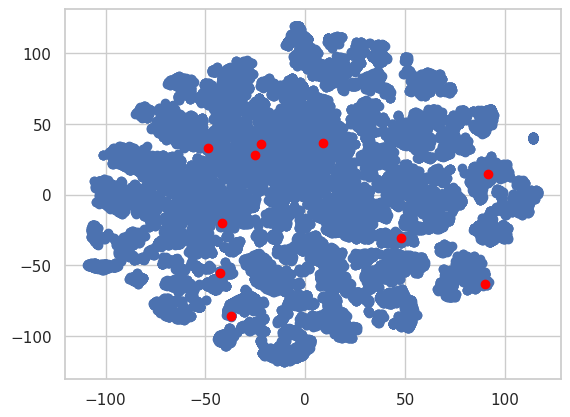

In [71]:
false_negative = ((y_labels == 1) & (y_test == 0))
top_fn = np.argsort(false_negative)[0:10]

tsne = TSNE(2)
X_new = tsne.fit_transform(X_test_s)
plt.scatter(X_new[:, 0], X_new[:, 1])
plt.scatter(X_new[top_fn, 0], X_new[top_fn, 1], color='red')
plt.show()

**Задание 6. (1 балл).** `sklearn` также предлагает нам и другие методы для поиска аномалий. В этом задании мы предлагаем вам сделать следующее:

Для начала попробуйте использовать методы Local Outlier Factor и One-Class SVM. Сравните результаты с IF и EIF.  

In [24]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [ ]:
lof = LocalOutlierFactor(novelty=True)
lof.fit(X_train_s, y_train)

In [26]:
y_scores = lof.score_samples(X_test)
y_labels = lof.predict(X_test_s)

print(f"PR AUC: {pr_auc_score(y_test, y_scores)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_labels)}")
print(f"MCC: {mcc(y_test, y_labels)}")

PR AUC: 0.0006259704231463287
Cohen Kappa Coef: -0.00023769427377077584
MCC: -0.0037146893224251167


In [ ]:
svm = OneClassSVM()
svm.fit(X_train_s, y_train)
y_scores = 1 - svm.score_samples(X_test)
y_labels = (svm.predict(X_test_s) == -1).astype(int)

print(f"PR AUC: {pr_auc_score(y_test, y_scores)}")
print(f"Cohen Kappa Coef: {cohen_kappa(y_test, y_labels)}")
print(f"MCC: {mcc(y_test, y_labels)}")

У вас началась депрессия из-за плохих метрик? Не беда! Сейчас давайте сделаем так: все методы, опробованные в этой части, попробуем задействовать для создания дополнительных признаков в данных. Проделайте это (не забудьте, что обучаться здесь нужно на трейне). Теперь возьмите лучшую модель из предыдущей части и обучите на новых данных. Смогли ли unsupervised-методы повысить вам качество?

In [ ]:
X_train_new = np.concat([X_train, ])

**Бонус. (0.1 балла).**

При сдаче проверяющий запустит следующую клетку один раз. Если она даст положительный результат, вы получите 0.1 бонусных балла. Если она даст отрицательный результат, вы получите -0.1 бонусных балла.

Если вы хотите отказаться от сдачи данного задания, допишите "хочу" после двоеточия: `your text here`

Ниже вы можете попрактиковаться и оценить ваши силы (изменять код ячейки запрещается!)

In [ ]:
import random

rng = random.SystemRandom(0)
rng.uniform(-1.0, 1.0)

PR_AUC: https://coralogix.com/ai-blog/ultimate-guide-to-pr-auc-calculations-uses-and-limitations/